In [2]:
from pathlib import Path
import gzip
import json
from pprint import pprint
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
from stable_platform_matchings.domain.instance import Instance
import seaborn as sns

In [3]:
sns.set_theme(context="paper", style="ticks")

In [4]:
root = Path("../results/exp_3")
all_jsons = list(root.rglob("*.json.gz"))
graph_data_filename = "../data/graph_0-14960_00_new.pickle"
instance = Instance.from_yaml(Path('../data/anon_14_day_instances/2020-08-27.yaml'))

In [5]:
import gzip
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# ============================================================
# SETTINGS
# ============================================================

# Example:
# all_jsons = sorted(Path("results/exp_3").glob("job_*/*.json.gz"))

LC_TO_USD = instance.lc_to_usd
TRUCK_FIXED_COST = instance.truck_fixed_cost

MAX_DEVIATION_POTENTIAL = 12

DEV_POT_BINS = np.linspace(2, 12, 7)
COST_BINS = np.linspace(65, 110, 7)

ZERO_TOL = 1e-8


# ============================================================
# PLOTTING STYLE
# ============================================================

def currency_formatter(x, pos):
    return f"${x:.0f}"


plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})


# ============================================================
# LOAD PAIRED DATA
# ============================================================

data_no_pay = []
data_pay = []

for file in all_jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        aggregate_payload = json.load(f)

    job_id = aggregate_payload["job_id"]

    for payload in aggregate_payload["runs"]:
        run_index = payload["metadata"]["run_index"]

        instance_snapshot = payload["summary_no_pay"]["instance_snapshot"]
        instance_id = instance_snapshot["instance_id"]

        epsilons = payload["sampled_inputs"]["epsilons"]
        het_costs = payload["sampled_inputs"]["het_costs"]
        intermediaries = instance_snapshot["intermediaries"]

        treatment_results = {
            "no_pay": payload["summary_no_pay"]["platform_solve_result"],
            "pay": payload["summary_pay"]["platform_solve_result"],
        }

        total_fruit_value = sum(
            quantity * instance.fruit_price_per_ton 
            for quantity in payload["sampled_inputs"]["quantities"].values()
        )

        for intermediary in intermediaries:
            intermediary_id = intermediary["id"]

            epsilon = epsilons[intermediary_id]
            het_cost = het_costs[intermediary_id]
            status_quo_quantity = intermediary["status_quo_quantity"]

            deviation_potential = (
                epsilon + status_quo_quantity
            )

            common = {
                "job_id": job_id,
                "run_index": run_index,
                "instance_id": instance_id,
                "intermediary_id": intermediary_id,
                "epsilon": epsilon,
                "het_cost": het_cost,
                "status_quo_quantity": status_quo_quantity,
                "deviation_potential": deviation_potential,
                "total_fruit_value": total_fruit_value
            }

            for treatment, solve_result in treatment_results.items():
                primary_result = solve_result["primary_result"]

                max_int_result = solve_result[
                    "max_intermediary_welfare_result"
                ]

                max_farmer_result = solve_result[
                    "max_farmer_welfare_result"
                ]

                matched_max = float(
                    intermediary_id
                    in max_int_result["selected_intermediaries"]
                )

                matched_min = float(
                    intermediary_id
                    in max_farmer_result["selected_intermediaries"]
                )

                profit_max = (
                    max_int_result["intermediary_profits"][
                        intermediary_id
                    ]
                    / LC_TO_USD
                )

                profit_min = (
                    max_farmer_result["intermediary_profits"][
                        intermediary_id
                    ]
                    / LC_TO_USD
                )

                # PRIMARY platform objective
                platform_profit = (
                    primary_result["platform_profit"]
                    / LC_TO_USD
                )

                row = {
                    **common,
                    "matched": matched_max,
                    "matched_max": matched_max,
                    "matched_min": matched_min,
                    "profit_max": profit_max,
                    "profit_min": profit_min,
                    "platform_profit": platform_profit,
                }

                if treatment == "no_pay":
                    data_no_pay.append(row)
                else:
                    data_pay.append(row)


df_no_pay = pd.DataFrame(data_no_pay)
df_pay = pd.DataFrame(data_pay)


In [7]:


# ============================================================
# PREPARE EACH DATAFRAME
# ============================================================

def prepare_df(df):
    df = df.copy()

    df = df[
        df["deviation_potential"] <= MAX_DEVIATION_POTENTIAL
    ].copy()

    df["total_fixed_cost"] = (
        df["het_cost"] + TRUCK_FIXED_COST
    ) / LC_TO_USD

    df["dev_pot_bin"] = (
        np.digitize(
            df["deviation_potential"],
            DEV_POT_BINS,
        ) - 1
    )

    df["cost_bin"] = (
        np.digitize(
            df["total_fixed_cost"],
            COST_BINS,
        ) - 1
    )

    # Drop observations outside the displayed bin ranges
    df = df[
        df["dev_pot_bin"].between(
            0,
            len(DEV_POT_BINS) - 2,
        )
        & df["cost_bin"].between(
            0,
            len(COST_BINS) - 2,
        )
    ].copy()

    return df


df_no_pay = prepare_df(df_no_pay)
df_pay = prepare_df(df_pay)


# ============================================================
# CREATE EXACT PAIRED DATAFRAME
# ============================================================

pair_cols = [
    "job_id",
    "run_index",
    "intermediary_id",
]

assert not df_no_pay.duplicated(pair_cols).any()
assert not df_pay.duplicated(pair_cols).any()

paired = df_no_pay.merge(
    df_pay,
    on=pair_cols,
    suffixes=("_no_pay", "_pay"),
    validate="one_to_one",
)

print("Rows no-pay:", len(df_no_pay))
print("Rows pay:", len(df_pay))
print("Paired rows:", len(paired))


# Verify that the paired rows really share the same inputs
for col in [
    "instance_id",
    "epsilon",
    "het_cost",
    "status_quo_quantity",
    "deviation_potential",
]:
    if pd.api.types.is_numeric_dtype(paired[f"{col}_no_pay"]):
        assert np.allclose(
            paired[f"{col}_no_pay"],
            paired[f"{col}_pay"],
            equal_nan=True,
        )
    else:
        assert (
            paired[f"{col}_no_pay"]
            == paired[f"{col}_pay"]
        ).all()


# ============================================================
# DEFINE PAIRED TREATMENT EFFECTS
# pay unmatched - cannot pay unmatched
# ============================================================

paired["delta_profit_max"] = (
    paired["profit_max_pay"]
    - paired["profit_max_no_pay"]
)

paired["delta_profit_min"] = (
    paired["profit_min_pay"]
    - paired["profit_min_no_pay"]
)

paired["delta_matched"] = (
    paired["matched_pay"]
    - paired["matched_no_pay"]
)

paired["matching_changed"] = (
    paired["matched_pay"]
    != paired["matched_no_pay"]
)

paired["became_matched"] = (
    (paired["matched_no_pay"] == 0)
    & (paired["matched_pay"] == 1)
)

paired["became_unmatched"] = (
    (paired["matched_no_pay"] == 1)
    & (paired["matched_pay"] == 0)
)

paired["profit_increased"] = (
    paired["delta_profit_max"] > ZERO_TOL
)

paired["profit_decreased"] = (
    paired["delta_profit_max"] < -ZERO_TOL
)

paired["positive_profit_pay"] = (
    paired["profit_max_pay"] > ZERO_TOL
)

paired["positive_profit_no_pay"] = (
    paired["profit_max_no_pay"] > ZERO_TOL
)

paired["unmatched_paid_profit"] = (
    (paired["matched_pay"] == 0)
    & (paired["profit_max_pay"] > ZERO_TOL)
)

# Bins are identical across treatment/control, so just keep one copy
paired["dev_pot_bin"] = paired["dev_pot_bin_no_pay"]
paired["cost_bin"] = paired["cost_bin_no_pay"]
paired["deviation_potential"] = (
    paired["deviation_potential_no_pay"]
)
paired["total_fixed_cost"] = (
    paired["total_fixed_cost_no_pay"]
)


# ============================================================
# BIN LABEL HELPERS
# ============================================================

dev_bin_labels = [
    f"{DEV_POT_BINS[i]:.1f}–{DEV_POT_BINS[i + 1]:.1f}"
    for i in range(len(DEV_POT_BINS) - 1)
]

cost_bin_labels = [
    f"${COST_BINS[i]:.0f}–${COST_BINS[i + 1]:.0f}"
    for i in range(len(COST_BINS) - 1)
]

dev_bin_centers = (
    DEV_POT_BINS[:-1] + DEV_POT_BINS[1:]
) / 2

cost_bin_centers = (
    COST_BINS[:-1] + COST_BINS[1:]
) / 2


# ============================================================
# SUMMARY STATISTICS
# ============================================================

print("\n=== Overall paired effects ===")

print(
    "Mean Δ max intermediary profit:",
    paired["delta_profit_max"].mean(),
)

print(
    "Median Δ max intermediary profit:",
    paired["delta_profit_max"].median(),
)

print(
    "Fraction with higher max profit:",
    paired["profit_increased"].mean(),
)

print(
    "Fraction with lower max profit:",
    paired["profit_decreased"].mean(),
)

print(
    "Fraction whose matching status changes:",
    paired["matching_changed"].mean(),
)

print(
    "Fraction becoming matched:",
    paired["became_matched"].mean(),
)

print(
    "Fraction becoming unmatched:",
    paired["became_unmatched"].mean(),
)

print(
    "Fraction unmatched but earning positive max profit "
    "when unmatched payments are allowed:",
    paired["unmatched_paid_profit"].mean(),
)

Rows no-pay: 31258
Rows pay: 31258
Paired rows: 31258

=== Overall paired effects ===
Mean Δ max intermediary profit: 3.2822927337852623
Median Δ max intermediary profit: 0.0
Fraction with higher max profit: 0.24275385501311664
Fraction with lower max profit: 0.037462409623136475
Fraction whose matching status changes: 0.04395674707274937
Fraction becoming matched: 0.02223430801714761
Fraction becoming unmatched: 0.021722439055601766
Fraction unmatched but earning positive max profit when unmatched payments are allowed: 0.1553202380190671


In [8]:
run_cols = [
    "job_id",
    "run_index",
]

runs = (
    paired
    .groupby(run_cols, as_index=False)
    .agg(
        instance_id=("instance_id_no_pay", "first"),
        epsilon=("epsilon_no_pay", "first"),

        total_fruit_value=(
            "total_fruit_value_no_pay",
            "first",
        ),

        platform_profit_no_pay=(
            "platform_profit_no_pay",
            "first",
        ),

        platform_profit_pay=(
            "platform_profit_pay",
            "first",
        ),
    )
)

runs["profit_pct_no_pay"] = (
    100
    * runs["platform_profit_no_pay"]
    / runs["total_fruit_value"]
)

runs["profit_pct_pay"] = (
    100
    * runs["platform_profit_pay"]
    / runs["total_fruit_value"]
)

runs["delta_profit_pct"] = (
    runs["profit_pct_pay"]
    - runs["profit_pct_no_pay"]
)

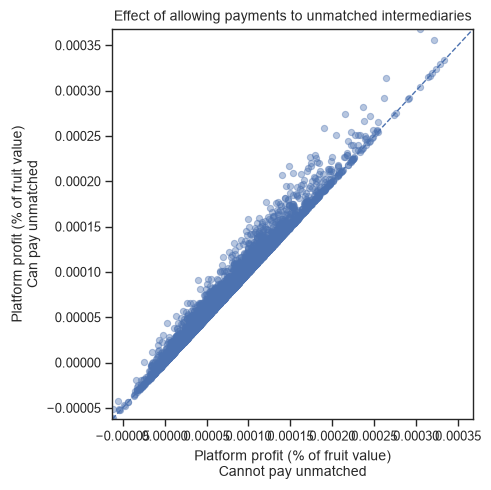

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))

x = runs["profit_pct_no_pay"]
y = runs["profit_pct_pay"]

ax.scatter(
    x,
    y,
    alpha=0.4,
    s=20,
)

lo = min(x.min(), y.min())
hi = max(x.max(), y.max())

ax.plot(
    [lo, hi],
    [lo, hi],
    linestyle="--",
    linewidth=1,
)

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)

ax.set_xlabel(
    "Platform profit (% of fruit value)\n"
    "Cannot pay unmatched"
)

ax.set_ylabel(
    "Platform profit (% of fruit value)\n"
    "Can pay unmatched"
)

ax.set_title(
    "Effect of allowing payments to unmatched intermediaries"
)

plt.tight_layout()
plt.show()

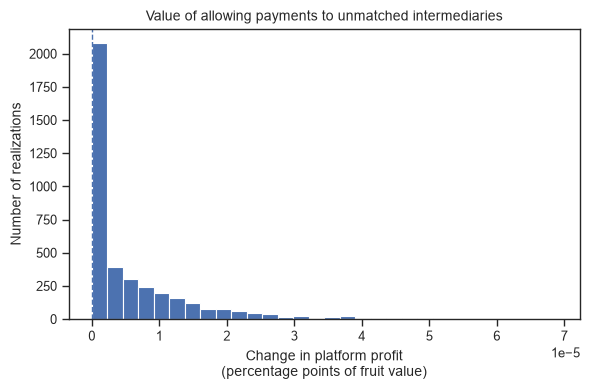

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    runs["delta_profit_pct"],
    bins=30,
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel(
    "Change in platform profit\n"
    "(percentage points of fruit value)"
)

ax.set_ylabel(
    "Number of realizations"
)

ax.set_title(
    "Value of allowing payments to unmatched intermediaries"
)

plt.tight_layout()
plt.show()

In [14]:
paired

,job_id,run_index,instance_id_no_pay,intermediary_id,epsilon_no_pay,het_cost_no_pay,status_quo_quantity_no_pay,deviation_potential_no_pay,total_fruit_value_no_pay,matched_no_pay,...,profit_increased,profit_decreased,positive_profit_pay,positive_profit_no_pay,unmatched_paid_profit,dev_pot_bin,cost_bin,deviation_potential,total_fixed_cost,added_profit
0,79,0,instance_11,hopeful_sanderson,1.754656,698115.360859,1.50,3.254656,56039900.0,0.0,...,False,False,False,False,False,0,5,3.254656,103.318301,0.000000e+00
1,79,0,instance_11,competent_mayer,1.088238,217529.319656,5.30,6.388238,56039900.0,1.0,...,True,False,True,True,False,2,0,6.388238,70.174436,2.299312e-04
2,79,0,instance_11,beautiful_bohr,5.430056,193260.707489,2.30,7.730056,56039900.0,1.0,...,True,False,True,True,False,3,0,7.730056,68.500738,2.782272e-04
3,79,0,instance_11,elegant_mendel,3.830788,169039.414701,0.00,3.830788,56039900.0,1.0,...,False,False,False,False,False,1,0,3.830788,66.830304,0.000000e+00
4,79,0,instance_11,elegant_gagarin,4.967535,468317.388322,4.00,8.967535,56039900.0,0.0,...,True,False,True,False,True,4,2,8.967535,87.470165,7.682163e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31253,212,9,instance_8,elegant_mendel,2.733452,436153.909086,4.85,7.583452,82929000.0,1.0,...,False,False,True,True,False,3,2,7.583452,85.251994,2.691394e-10
31254,212,9,instance_8,elegant_gagarin,3.724567,701189.140261,0.00,3.724567,82929000.0,0.0,...,False,False,False,False,False,1,5,3.724567,103.530286,0.000000e+00
31255,212,9,instance_8,vigorous_mccarthy,4.315688,758791.866825,0.00,4.315688,82929000.0,0.0,...,False,False,False,False,False,1,5,4.315688,107.502887,0.000000e+00
31256,212,9,instance_8,gallant_cerf,2.823263,724575.320363,1.24,4.063263,82929000.0,0.0,...,False,False,False,False,False,1,5,4.063263,105.143126,0.000000e+00


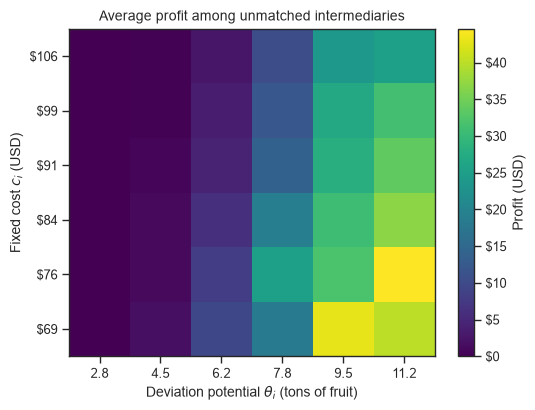

In [18]:
unmatched_only = paired[
    paired["matched_pay"] == 0
].copy()

unmatched_profit_heat = unmatched_only.pivot_table(
    index="cost_bin",
    columns="dev_pot_bin",
    values="profit_max_pay",
    aggfunc="mean",
)

unmatched_profit_heat = unmatched_profit_heat.reindex(
    index=range(len(COST_BINS) - 1),
    columns=range(len(DEV_POT_BINS) - 1),
)

fig, ax = plt.subplots(figsize=(5.5, 4.2))

im = ax.imshow(
    unmatched_profit_heat.values,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

ax.set_xticks(
    np.arange(len(dev_bin_centers))
)
ax.set_xticklabels(
    [f"{x:.1f}" for x in dev_bin_centers]
)


ax.set_yticks(
    np.arange(len(cost_bin_centers))
)
ax.set_yticklabels(
    [f"${x:.0f}" for x in cost_bin_centers]
)

ax.set_xlabel(
    r"Deviation potential $\theta_i$ (tons of fruit)"
)
ax.set_ylabel(
    r"Fixed cost $c_i$ (USD)"
)

ax.set_title(
    "Average profit among unmatched intermediaries"
)

cbar = fig.colorbar(
    im,
    ax=ax,
)

cbar.set_label(
    "Profit (USD)"
)

cbar.ax.yaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.tight_layout()
plt.show()

In [12]:
# Among cases where profit changes at all,
# how often does matching remain unchanged?
changed_profit = np.abs(paired["delta_profit_max"]) > 1e-8

print(
    "Among profit-changing cases, fraction with unchanged matching:",
    (
        changed_profit
        & ~paired["matching_changed"]
    ).sum() / changed_profit.sum()
)

# Among unmatched intermediaries under pay_unmatched=True,
# how often do they actually get positive profit?
unmatched_pay = paired["matched_pay"] == 0

print(
    "Among unmatched under pay regime, fraction with positive profit:",
    paired.loc[
        unmatched_pay,
        "positive_profit_pay"
    ].mean()
)

Among profit-changing cases, fraction with unchanged matching: 0.9370932754880694
Among unmatched under pay regime, fraction with positive profit: 0.2478811395895027


In [13]:
paired["added_profit"] = paired["delta_profit_max"].clip(lower=0)

added_to_unmatched = paired.loc[
    paired["matched_pay"] == 0,
    "added_profit"
].sum()

added_to_matched = paired.loc[
    paired["matched_pay"] == 1,
    "added_profit"
].sum()

total_added = paired["added_profit"].sum()

print(
    "Share of added profit going to unmatched:",
    added_to_unmatched / total_added
)

print(
    "Share of added profit going to matched:",
    added_to_matched / total_added
)

Share of added profit going to unmatched: 0.7678021630642788
Share of added profit going to matched: 0.23219783693572107


In [9]:
same_match = paired[~paired["matching_changed"]]

print(
    "Mean Δ profit, same matching:",
    same_match["delta_profit_max"].mean()
)

print(
    "Fraction with higher profit, same matching:",
    (same_match["delta_profit_max"] > 1e-8).mean()
)

Mean Δ profit, same matching: 3.2479084571271506
Fraction with higher profit, same matching: 0.23875652523089277


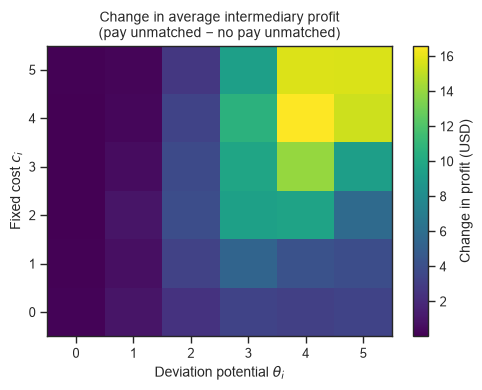

In [17]:
heat = paired.pivot_table(
    index="cost_bin_no_pay",
    columns="dev_pot_bin_no_pay",
    values="delta_profit_max",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(5, 4))

lim = np.nanmax(np.abs(heat.values))

im = ax.imshow(
    heat.values,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

ax.set_xlabel(r"Deviation potential $\theta_i$")
ax.set_ylabel(r"Fixed cost $c_i$")
ax.set_title(
    "Change in average intermediary profit\n"
    "(pay unmatched − no pay unmatched)"
)

fig.colorbar(
    im,
    ax=ax,
    label="Change in profit (USD)",
)

plt.tight_layout()
plt.show()

## Matchings

In [43]:
# ============================================================
# ADD FRUIT VALUE DURING DATA LOADING
# ============================================================

farmers = instance_snapshot["farmers"]

total_fruit_quantity = sum(
    farmer["quantity"]
    for farmer in farmers
)

total_fruit_value = (
    total_fruit_quantity
    * instance.fruit_price_per_ton
    / LC_TO_USD
)

In [44]:
data_no_pay = []
data_pay = []

for file in all_jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        aggregate_payload = json.load(f)

    for payload in aggregate_payload["runs"]:
        instance_snapshot = payload["summary_no_pay"]["instance_snapshot"]
        instance_id = instance_snapshot["instance_id"]

        epsilons = payload["sampled_inputs"]["epsilons"]
        het_costs = payload["sampled_inputs"]["het_costs"]
        intermediaries = instance_snapshot["intermediaries"]

        results = {
            "no_pay": payload["summary_no_pay"]["platform_solve_result"],
            "pay": payload["summary_pay"]["platform_solve_result"],
        }

        for intermediary in intermediaries:
            intermediary_id = intermediary["id"]

            epsilon = epsilons[intermediary_id]
            het_cost = het_costs[intermediary_id]
            status_quo_quantity = intermediary["status_quo_quantity"]
            deviation_potential = epsilon + status_quo_quantity

            common = {
                "epsilon": epsilon,
                "het_cost": het_cost,
                "status_quo_quantity": status_quo_quantity,
                "deviation_potential": deviation_potential,
                "instance_id": instance_id,
                "intermediary_id": intermediary_id,
                "total_fruit_value": total_fruit_value,
            }

            for treatment, solve_result in results.items():
                max_int_result = solve_result[
                    "max_intermediary_welfare_result"
                ]
                max_farmer_result = solve_result[
                    "max_farmer_welfare_result"
                ]

                row = {
                    **common,
                    "matched": float(
                        intermediary_id
                        in max_int_result["selected_intermediaries"]
                    ),
                    "profit_max": (
                        max_int_result["intermediary_profits"][intermediary_id]
                        / instance.lc_to_usd
                    ),
                    "profit_min": (
                        max_farmer_result["intermediary_profits"][intermediary_id]
                        / instance.lc_to_usd
                    ),
                }

                if treatment == "no_pay":
                    data_no_pay.append(row)
                else:
                    data_pay.append(row)

df_no_pay = pd.DataFrame(data_no_pay)
df_pay = pd.DataFrame(data_pay)

In [45]:
def prepare_df(df):
    df = df.copy()

    df = df[df["deviation_potential"] <= 12]

    df["total_fixed_cost"] = (
        df["het_cost"] + instance.truck_fixed_cost
    ) / instance.lc_to_usd

    dev_pot_bins = np.linspace(2, 12, 7)
    cost_bins = np.linspace(65, 110, 7)

    df["dev_pot_bin"] = (
        np.digitize(
            df["deviation_potential"],
            dev_pot_bins,
        ) - 1
    )

    df["cost_bin"] = (
        np.digitize(
            df["total_fixed_cost"],
            cost_bins,
        ) - 1
    )

    return df


df_no_pay = prepare_df(df_no_pay)
df_pay = prepare_df(df_pay)

In [46]:
pair_cols = [
    "instance_id",
    "intermediary_id",
    "epsilon",
    "het_cost",
    "status_quo_quantity",
]

paired = df_no_pay.merge(
    df_pay,
    on=pair_cols,
    suffixes=("_no_pay", "_pay"),
    validate="one_to_one",
)

In [47]:
paired["delta_profit_max"] = (
    paired["profit_max_pay"]
    - paired["profit_max_no_pay"]
)

paired["delta_profit_min"] = (
    paired["profit_min_pay"]
    - paired["profit_min_no_pay"]
)

paired["delta_matched"] = (
    paired["matched_pay"]
    - paired["matched_no_pay"]
)

paired["matching_changed"] = (
    paired["matched_pay"]
    != paired["matched_no_pay"]
)

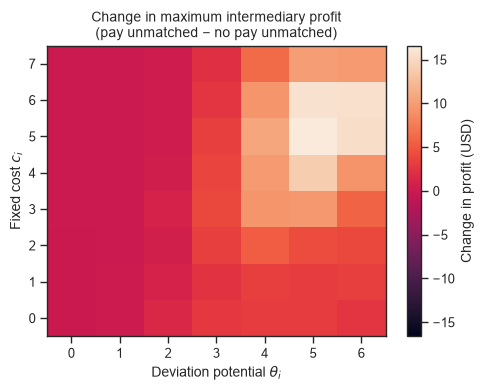

In [ ]:
heat = paired.pivot_table(
    index="cost_bin_no_pay",
    columns="dev_pot_bin_no_pay",
    values="delta_profit_max",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(5, 4))

lim = np.nanmax(np.abs(heat.values))

im = ax.imshow(
    heat.values,
    origin="lower",
    aspect="auto",
    vmin=-lim,
    vmax=lim,
    cmap="viridis"
)

ax.set_xlabel(r"Deviation potential $\theta_i$")
ax.set_ylabel(r"Fixed cost $c_i$")
ax.set_title(
    "Change in maximum intermediary profit\n"
    "(pay unmatched − no pay unmatched)"
)

fig.colorbar(
    im,
    ax=ax,
    label="Change in profit (USD)",
)

plt.tight_layout()
plt.show()

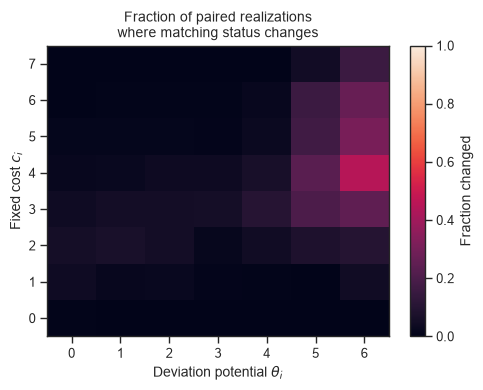

In [15]:
heat_match = paired.pivot_table(
    index="cost_bin_no_pay",
    columns="dev_pot_bin_no_pay",
    values="matching_changed",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(
    heat_match.values,
    origin="lower",
    aspect="auto",
    vmin=0,
    vmax=1,
)

ax.set_xlabel(r"Deviation potential $\theta_i$")
ax.set_ylabel(r"Fixed cost $c_i$")
ax.set_title(
    "Fraction of paired realizations\n"
    "where matching status changes"
)

fig.colorbar(
    im,
    ax=ax,
    label="Fraction changed",
)

plt.tight_layout()
plt.show()

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Adjust these to your actual identifiers
pair_cols = ["job_id", "run_index", "intermediary_id"]

# Sanity checks
assert not df_pay.duplicated(pair_cols).any()
assert not df_no_pay.duplicated(pair_cols).any()

paired = df_no_pay.merge(
    df_pay,
    on=pair_cols,
    suffixes=("_no_pay", "_pay"),
    validate="one_to_one",
)

print("no-pay rows:", len(df_no_pay))
print("pay rows:", len(df_pay))
print("paired rows:", len(paired))

KeyError: Index(['job_id', 'run_index'], dtype='str')

### Figure: Heatmap of Intermediary Match Rate vs. Fixed Cost and Deviation Potential

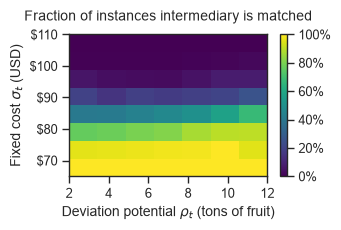

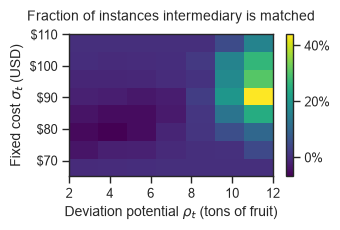

In [ ]:
# compute probability that matched = 1 in each (deviation_potential, total_fixed_cost) bin
heatmap_pay = (
    df_pay
    .groupby(['dev_pot_bin', 'cost_bin'])
    ['matched']
    .mean()
    .unstack() 
    * 100
)

heatmap_no_pay = (
    df_no_pay
    .groupby(['dev_pot_bin', 'cost_bin'])
    ['matched']
    .mean()
    .unstack() 
    * 100
)

diff = heatmap_no_pay - heatmap_pay

# plot heatmap
plt.figure(figsize=(3.5, 2.4))
plt.imshow(
    heatmap_pay.T, origin='lower', aspect='auto',
    extent=(dev_pot_bins[0], dev_pot_bins[-1], cost_bins[0], cost_bins[-1]),
    cmap='viridis'
)
cbar = plt.colorbar()

# format colorbar ticks as percentages
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.xlabel(r'Deviation potential $\rho_t$ (tons of fruit)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.ylabel(r'Fixed cost $\sigma_t$ (USD)')
plt.title(r'Fraction of instances intermediary is matched', pad=10)
plt.tight_layout()
plt.savefig("../figures/exp_3/matched_heatplot.png", bbox_inches='tight', dpi=300) 
plt.show()

# plot heatmap
plt.figure(figsize=(3.5, 2.4))
plt.imshow(
    diff.T, origin='lower', aspect='auto',
    extent=(dev_pot_bins[0], dev_pot_bins[-1], cost_bins[0], cost_bins[-1]),
    cmap='viridis'
)
cbar = plt.colorbar()

# format colorbar ticks as percentages
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.xlabel(r'Deviation potential $\rho_t$ (tons of fruit)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.ylabel(r'Fixed cost $\sigma_t$ (USD)')
plt.title(r'Fraction of instances intermediary is matched\n(change)', pad=10)
plt.tight_layout()
plt.savefig("../figures/exp_3/matched_diff.png", bbox_inches='tight', dpi=300) 
plt.show()

### Figure: Heatmap of Average Intermediary Profit vs. Fixed Cost and Deviation Potential

In [1]:
heatmap_pay = df_pay.groupby(['dev_pot_bin', 'cost_bin'])['profit_max'].mean().unstack()
heatmap_no_pay = df_no_pay.groupby(['dev_pot_bin', 'cost_bin'])['profit_max'].mean().unstack()

diff = heatmap_pay - heatmap_no_pay

# Plot heatmap
plt.figure(figsize=(3.5, 2.4))
plt.imshow(
    heatmap_pay.T, origin='lower', aspect='auto',
    extent=(dev_pot_bins[0], dev_pot_bins[-1], cost_bins[0], cost_bins[-1]),
    cmap='viridis'
)

plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.ylabel(r'Fixed cost $\sigma_t$ (USD)')
cbar = plt.colorbar(label='')
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:.0f}'))

plt.xlabel(r'Deviation potential $\rho_t$ (tons of fruit)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.title(r"Average intermediary profit", pad=10)
plt.tight_layout()

plt.savefig("../figures/exp_3/intermediary_profit.png", bbox_inches='tight', dpi=300) 
plt.show()

plt.figure(figsize=(3.5, 2.4))
plt.imshow(
    diff.T, origin='lower', aspect='auto',
    extent=(dev_pot_bins[0], dev_pot_bins[-1], cost_bins[0], cost_bins[-1]),
    cmap='viridis'
)

plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.ylabel(r'Fixed cost $\sigma_t$ (USD)')
cbar = plt.colorbar(label='')
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:.0f}'))

plt.xlabel(r'Deviation potential $\rho_t$ (tons of fruit)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.title(r"Change in average intermediary profit", pad=10)
plt.tight_layout()

plt.savefig("../figures/exp_3/intermediary_profit_diff.png", bbox_inches='tight', dpi=300) 
plt.show()

NameError: name 'df_pay' is not defined

## Pricing and Payments

In [ ]:
data = []
for file in all_jsons:
    with gzip.open(file, 'rt', encoding='utf-8') as f:
        aggregate_payload = json.load(f)
    for payload in aggregate_payload["runs"]:
        instance_id = payload["summary_pay"]["instance_snapshot"]["instance_id"]
        epsilons = payload["sampled_inputs"]["epsilons"]
        het_costs = payload["sampled_inputs"]["het_costs"]
        quantities = payload["sampled_inputs"]["quantities"]

        farmers = payload["summary_pay"]["instance_snapshot"]["farmers"]
        intermediaries = payload["summary_pay"]["instance_snapshot"]["intermediaries"]
        max_int_result = payload["summary_pay"]["platform_solve_result"]["max_intermediary_welfare_result"]
        max_farmer_result = payload["summary_pay"]["platform_solve_result"]["max_farmer_welfare_result"]

        for farmer in farmers:
            farmer_id = farmer["id"]
            intermediary_id = farmer["intermediary_id"]

            quantity = quantities[farmer_id]
            payment_min = max_int_result["farmer_payments"][farmer_id]
            payment_max = max_farmer_result["farmer_payments"][farmer_id]

            intermediary = next(
                intermediary for intermediary in intermediaries 
                if intermediary["id"] == intermediary_id
            )

            intermediary_deviation_potential = (
                epsilons[intermediary_id] + intermediary["status_quo_quantity"]
            )
            intermediary_matched = max_int_result["intermediary_profits"][intermediary_id] > 10
            payment_per_kg = max_int_result["farmer_payments"][farmer_id] / quantities[farmer_id]

            

            data.append({
                "quantity": quantity,
                "instance_id": instance_id,
                "payment_min": payment_min,
                "payment_max": payment_max,
                "farmer_id": farmer_id,
                "dirt_to_mill": farmer["dirt_to_mill"] /(2625)/4,
                "paved_to_mill": farmer["paved_to_mill"] /(2625),
                "intermediary_deviation_potential": intermediary_deviation_potential,
                "intermediary_matched": intermediary_matched,
                "payment_per_kg": payment_per_kg / instance.lc_to_usd
            })  

df_pay = pd.DataFrame(data)


In [ ]:
data = []
for file in all_jsons:
    with gzip.open(file, 'rt', encoding='utf-8') as f:
        aggregate_payload = json.load(f)
    for payload in aggregate_payload["runs"]:
        instance_id = payload["summary_no_pay"]["instance_snapshot"]["instance_id"]
        epsilons = payload["sampled_inputs"]["epsilons"]
        het_costs = payload["sampled_inputs"]["het_costs"]
        quantities = payload["sampled_inputs"]["quantities"]

        farmers = payload["summary_no_pay"]["instance_snapshot"]["farmers"]
        intermediaries = payload["summary_no_pay"]["instance_snapshot"]["intermediaries"]
        max_int_result = payload["summary_no_pay"]["platform_solve_result"]["max_intermediary_welfare_result"]
        max_farmer_result = payload["summary_no_pay"]["platform_solve_result"]["max_farmer_welfare_result"]

        for farmer in farmers:
            farmer_id = farmer["id"]
            intermediary_id = farmer["intermediary_id"]

            quantity = quantities[farmer_id]
            payment_min = max_int_result["farmer_payments"][farmer_id]
            payment_max = max_farmer_result["farmer_payments"][farmer_id]

            intermediary = next(
                intermediary for intermediary in intermediaries 
                if intermediary["id"] == intermediary_id
            )

            intermediary_deviation_potential = (
                epsilons[intermediary_id] + intermediary["status_quo_quantity"]
            )
            intermediary_matched = max_int_result["intermediary_profits"][intermediary_id] > 10
            payment_per_kg = max_int_result["farmer_payments"][farmer_id] / quantities[farmer_id]

            

            data.append({
                "quantity": quantity,
                "instance_id": instance_id,
                "payment_min": payment_min,
                "payment_max": payment_max,
                "farmer_id": farmer_id,
                "dirt_to_mill": farmer["dirt_to_mill"] /(2625)/4,
                "paved_to_mill": farmer["paved_to_mill"] /(2625),
                "intermediary_deviation_potential": intermediary_deviation_potential,
                "intermediary_matched": intermediary_matched,
                "payment_per_kg": payment_per_kg / instance.lc_to_usd
            })  

df_no_pay = pd.DataFrame(data)


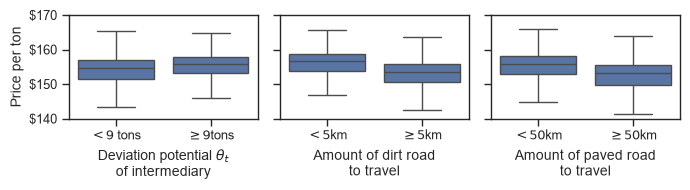

In [ ]:
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

def dollar_formatter(x, pos):
    return f'${int(x)}'

formatter = FuncFormatter(dollar_formatter)

df_pay['int_dev_pot_bin'] = pd.cut(
    df_pay['intermediary_deviation_potential'],
    bins=[-float('inf'), 9, float('inf')],
    labels=[r'$< 9$ tons', r'$\geq 9$tons']
)

df_pay['dirt_to_mill_bin'] = pd.cut(
    df_pay['dirt_to_mill'],
    bins=[-float('inf'), 5, float('inf')],
    labels=[r'$< 5$km', r'$\geq 5$km']
)

df_pay['paved_to_mill_bin'] = pd.cut(
    df_pay['paved_to_mill'],
    bins=[-float('inf'), 50, float('inf')],
    labels=[r'$< 50$km', r'$\geq 50$km']
)

fig, axes = plt.subplots(1, 3, figsize=(7, 2), sharey=True)

# First plot: Power to Deviate
sns.boxplot(
    data=df_pay,
    x='int_dev_pot_bin',
    y='payment_per_kg',
    showfliers=False,
    ax=axes[0]
)

axes[0].set_xlabel(r'Deviation potential $\theta_t$'+'\nof intermediary')
axes[0].set_ylabel('Price per ton')
axes[0].set_ylim(130, 170)
axes[0].yaxis.set_major_formatter(formatter)

# Second plot: Dirt road
sns.boxplot(
    data=df_pay,
    x='dirt_to_mill_bin',
    y='payment_per_kg',
    showfliers=False,
    ax=axes[1]
)
axes[1].set_xlabel('Amount of dirt road\nto travel')
axes[1].set_ylabel('')
axes[1].set_ylim(130, 170)
axes[1].yaxis.set_major_formatter(formatter)

# Third plot: Paved road
sns.boxplot(
    data=df_pay,
    x='paved_to_mill_bin',
    y='payment_per_kg',
    showfliers=False,
    ax=axes[2]
)
axes[2].set_xlabel('Amount of paved road\nto travel')
axes[2].set_ylabel('')
axes[2].set_ylim(140, 170)
axes[2].yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.savefig("../figures/exp_3/boxplots_prices.png", bbox_inches='tight', dpi=300)

plt.show()


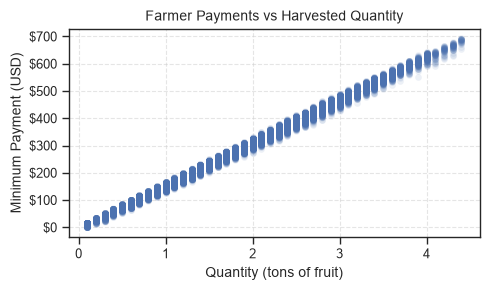

In [ ]:
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

plt.figure(figsize=(5, 3))

sns.scatterplot(
    data=df_pay,
    x='quantity',
    y=df_pay['payment_min'] / instance.lc_to_usd,
    alpha=0.1,
    edgecolor='k',
    linewidth=0,
)

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xlabel('Quantity (tons of fruit)')
plt.ylabel('Minimum Payment (USD)')
plt.title('Farmer Payments vs Harvested Quantity')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("../figures/exp_3/farmer_payments.png", bbox_inches='tight', dpi=300) 

plt.show()